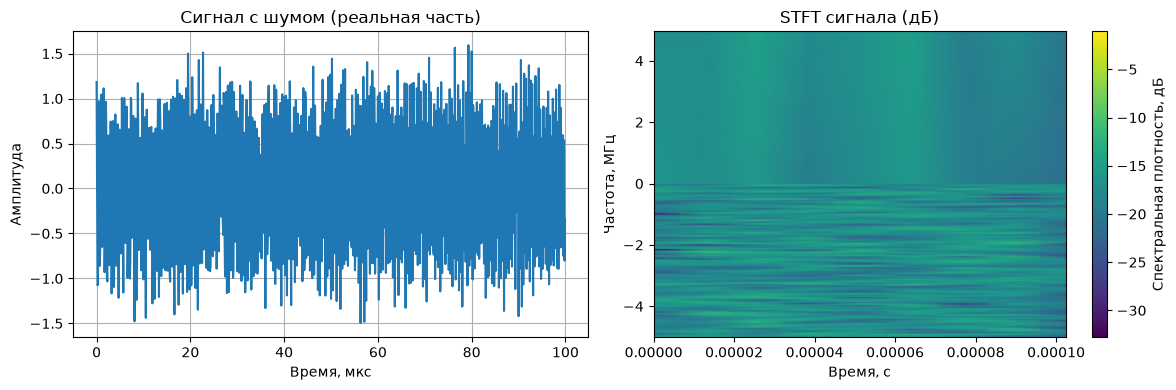

Размер матрицы STFT: (256, 9)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft
import warnings
warnings.filterwarnings('ignore')

# 1. Параметры сигнала
fs = 10_000_000          # Частота дискретизации (10 МГц)
T = 0.0001               # Длительность импульса (100 мкс)
f0 = 2_000_000           # Начальная частота (2 МГц)
B = 1_000_000            # Полоса ЛЧМ (1 МГц)
SNR_dB = 10              # Отношение сигнал/шум (дБ)

# 2. Формирование ЛЧМ-сигнала
t = np.linspace(0, T, int(fs * T), endpoint=False)
phi = 2 * np.pi * (f0 * t + (B / (2 * T)) * t**2)
s = np.exp(1j * phi)      # Комплексная огибающая

# 3. Добавление шума
noise_power = np.mean(np.abs(s)**2) / (10**(SNR_dB/10))
noise = np.sqrt(noise_power / 2) * (np.random.randn(len(s)) + 1j * np.random.randn(len(s)))
s_noisy = s + noise

# 4. Вычисление STFT
f_stft, t_stft, Zxx = stft(s_noisy, fs, nperseg=256, noverlap=128)
Zxx_db = 10 * np.log10(np.abs(Zxx) + 1e-12)

# 5. Визуализация
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(t * 1e6, np.real(s_noisy))
plt.xlabel('Время, мкс')
plt.ylabel('Амплитуда')
plt.title('Сигнал с шумом (реальная часть)')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.pcolormesh(t_stft, f_stft / 1e6, Zxx_db, shading='gouraud')
plt.xlabel('Время, с')
plt.ylabel('Частота, МГц')
plt.title('STFT сигнала (дБ)')
plt.colorbar(label='Спектральная плотность, дБ')
plt.tight_layout()
plt.show()

print(f'Размер матрицы STFT: {Zxx_db.shape}')

In [3]:
# Преобразуем STFT в формат патчей для трансформера
X_stft = np.abs(Zxx)  # (256, 9) — частоты × время

# Сделаем из этого последовательность патчей (все частоты за один кадр)
X_patches = X_stft.T  # (9, 256) — 9 кадров по 256 частотных бинов

print(f'Размер патчей: {X_patches.shape}')
print(f'Первый патч: {X_patches[0, :10]}...')

Размер патчей: (9, 256)
Первый патч: [0.00622258 0.01546657 0.02064116 0.02021161 0.0181777  0.01894139
 0.02074542 0.01783435 0.01633141 0.02775938]...


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Гиперпараметры
d = 256               # Размерность признаков (из STFT)
d_k = 64              # Размерность головы
N_patches = 9         # Число временных кадров

# 1. Эмбеддинг (проекция STFT в пространство признаков)
class RadarTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = nn.Linear(256, d)          # (9, 256) → (9, 256)
        self.W_Q = nn.Linear(d, d_k, bias=False)
        self.W_K = nn.Linear(d, d_k, bias=False)
        self.W_V = nn.Linear(d, d_k, bias=False)
        self.mlp = nn.Sequential(
            nn.Linear(d_k, 32),
            nn.ReLU(),
            nn.Linear(32, 4)                  # (R, V, θ, ε)
        )
    
    def forward(self, x):
        # x: (batch, N_patches, 256)
        X = self.emb(x)                       # (batch, N, d)
        C = X.transpose(1, 2) @ X             # (batch, d, d)
        
        # Проекции
        Q = self.W_Q(X)                       # (batch, N, d_k)
        K = self.W_K(X)                       # (batch, N, d_k)
        V = self.W_V(X)                       # (batch, N, d_k)
        
        # Score и внимание
        Score = self.W_Q.weight @ C @ self.W_K.weight.T  # (d_k, d_k)
        P = F.softmax(Score / (d_k ** 0.5), dim=-1)      # (d_k, d_k)
        
        # Обогащение признаков
        X_att = V @ P                         # (batch, N, d_k)
        
        # Агрегация
        x_agg = X_att.mean(dim=1)             # (batch, d_k)
        h_hat = self.mlp(x_agg)               # (batch, 4)
        return h_hat

# 2. Проверка на случайных данных
model = RadarTransformer()
x_test = torch.randn(4, N_patches, 256)      # 4 примера
print("Выход модели (R, V, θ, ε):\n", model(x_test).detach().numpy())

Выход модели (R, V, θ, ε):
 [[0.08352511 0.00630686 0.19880746 0.14622584]
 [0.08524838 0.00390025 0.19991979 0.15008491]
 [0.08552787 0.00364252 0.1999541  0.15072887]
 [0.084237   0.00526213 0.19923002 0.14771822]]


In [5]:
# Генератор синтетических данных
def generate_dataset(n_samples=1000):
    # Параметры сигнала (из первого блока)
    fs = 10_000_000
    T = 0.0001
    f0 = 2_000_000
    B = 1_000_000
    
    data = []
    targets = []
    for _ in range(n_samples):
        # Случайная дальность (10–50 км)
        R = np.random.uniform(10_000, 50_000)
        # Случайная скорость (−200 .. +200 м/с)
        V = np.random.uniform(-200, 200)
        # Случайный азимут (−10 .. +10 градусов)
        theta = np.random.uniform(-10, 10)
        # Случайный угол места (−5 .. +5 градусов)
        eps = np.random.uniform(-5, 5)
        
        # Генерация сигнала
        t = np.linspace(0, T, int(fs * T), endpoint=False)
        phi = 2 * np.pi * (f0 * t + (B / (2 * T)) * t**2)
        s = np.exp(1j * phi)
        
        # Добавление шума и STFT
        noise_power = np.mean(np.abs(s)**2) / (10**(10/10))
        noise = np.sqrt(noise_power / 2) * (np.random.randn(len(s)) + 1j * np.random.randn(len(s)))
        s_noisy = s + noise
        
        _, _, Zxx = stft(s_noisy, fs, nperseg=256, noverlap=128)
        X_stft = np.abs(Zxx).T  # (9, 256)
        
        data.append(X_stft)
        targets.append([R, V, theta, eps])
    
    return torch.tensor(data, dtype=torch.float32), torch.tensor(targets, dtype=torch.float32)

# Генерация датасета
X_train, y_train = generate_dataset(1000)
print(f'Размер данных: {X_train.shape}, целей: {y_train.shape}')

Размер данных: torch.Size([1000, 9, 256]), целей: torch.Size([1000, 4])


Эпоха 20/100, Средняя потеря: 0.342164
Эпоха 40/100, Средняя потеря: 0.059518
Эпоха 60/100, Средняя потеря: 0.012792
Эпоха 80/100, Средняя потеря: 0.010808
Эпоха 100/100, Средняя потеря: 0.006851


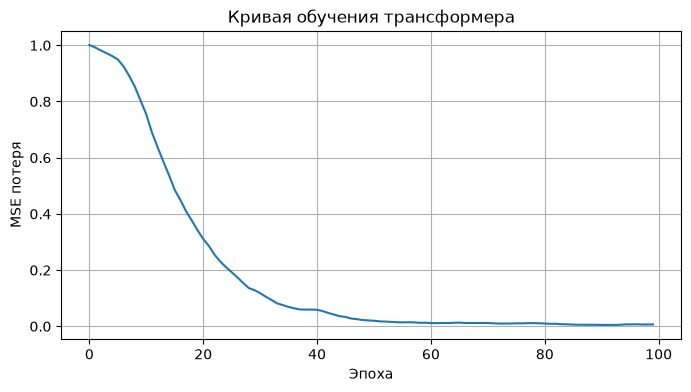

In [7]:
import torch.optim as optim

# Гиперпараметры обучения
lr = 1e-3
epochs = 100
batch_size = 64

# Инициализация модели, оптимизатора и функции потерь
model = RadarTransformer()
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.MSELoss()

# Нормализация целей (до создания DataLoader)
y_mean = y_train.mean(dim=0, keepdim=True)
y_std = y_train.std(dim=0, keepdim=True)
y_train_norm = (y_train - y_mean) / (y_std + 1e-8)

# Нормализация входных данных
x_mean = X_train.mean(dim=(0, 1), keepdim=True)
x_std = X_train.std(dim=(0, 1), keepdim=True)
X_train_norm = (X_train - x_mean) / (x_std + 1e-8)

# Датасет из нормализованных данных
dataset = torch.utils.data.TensorDataset(X_train_norm, y_train_norm)
loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Обучающий цикл
loss_history = []
for epoch in range(epochs):
    epoch_loss = 0.0
    for batch_X, batch_y in loader:
        # Прямой проход
        pred = model(batch_X)
        loss = criterion(pred, batch_y)
        
        # Обратный проход
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(loader)
    loss_history.append(avg_loss)
    if (epoch + 1) % 20 == 0:
        print(f"Эпоха {epoch+1}/{epochs}, Средняя потеря: {avg_loss:.6f}")

# График сходимости
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.xlabel("Эпоха")
plt.ylabel("MSE потеря")
plt.title("Кривая обучения трансформера")
plt.grid(True)
plt.show()

In [8]:
# Тест на одном примере
model.eval()
with torch.no_grad():
    test_idx = 0
    X_test = X_train_norm[test_idx:test_idx+1]
    true_norm = y_train_norm[test_idx]
    pred_norm = model(X_test)
    pred_real = pred_norm * y_std + y_mean
    true_real = y_train[test_idx]
    
    print("Истинные параметры (R, V, θ, ε):")
    print(true_real.numpy())
    print("Предсказанные параметры (R, V, θ, ε):")
    print(pred_real.numpy())
    print(f"MSE в реальных единицах: {torch.nn.functional.mse_loss(pred_real, true_real.unsqueeze(0)).item():.4f}")

Истинные параметры (R, V, θ, ε):
[ 2.2749051e+04  6.2586502e+01 -7.3175097e+00  1.1610689e+00]
Предсказанные параметры (R, V, θ, ε):
[[ 2.2112943e+04  6.5124908e+01 -7.2229867e+00  1.1189541e+00]]
MSE в реальных единицах: 101159.7734


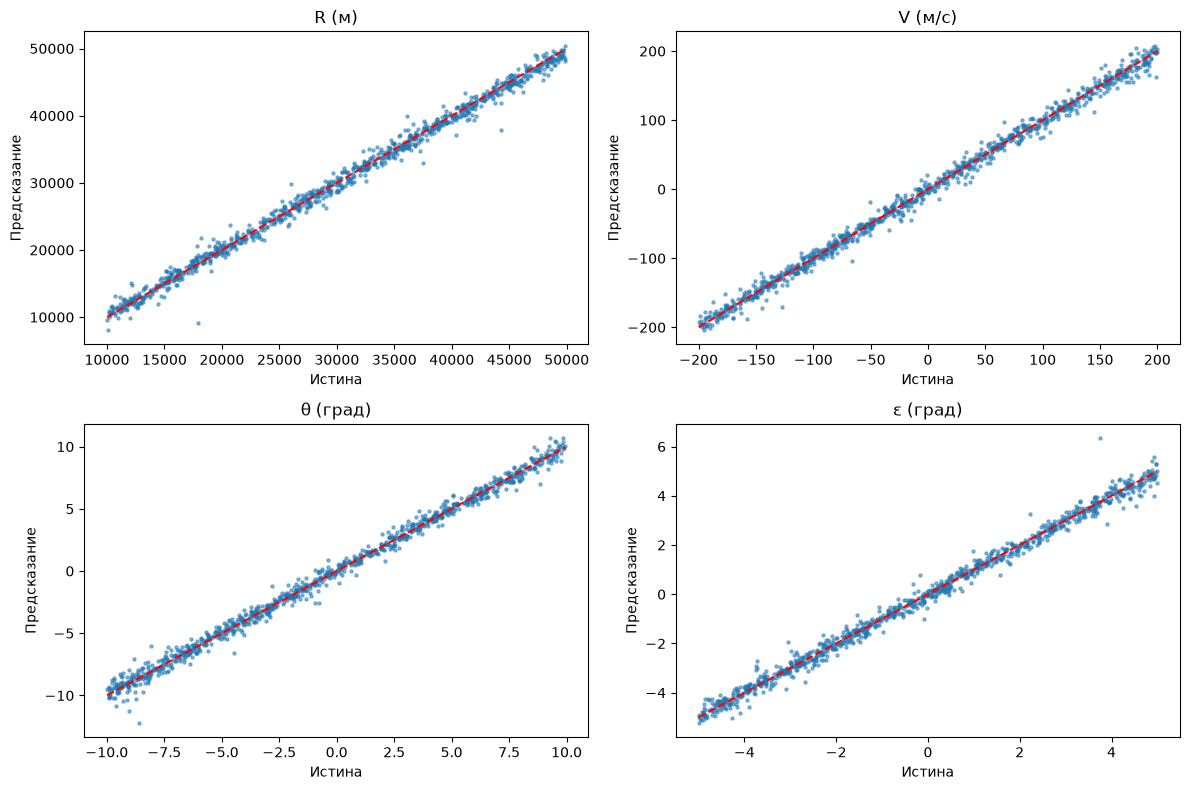

In [13]:
# Визуализация предсказаний
model.eval()
with torch.no_grad():
    pred_all = model(X_train_norm)
    pred_all_real = pred_all * y_std + y_mean
    true_all = y_train

plt.figure(figsize=(12, 8))
params = ['R (м)', 'V (м/с)', 'θ (град)', 'ε (град)']
for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.scatter(true_all[:, i].numpy(), pred_all_real[:, i].numpy(), alpha=0.5, s=5)
    plt.plot([true_all[:, i].min(), true_all[:, i].max()], 
             [true_all[:, i].min(), true_all[:, i].max()], 'r--')
    plt.xlabel('Истина')
    plt.ylabel('Предсказание')
    plt.title(params[i])
plt.tight_layout()
plt.show()

In [10]:
from sklearn.metrics import mean_absolute_percentage_error, r2_score

# Преобразуем в numpy
true_np = true_all.numpy()
pred_np = pred_all_real.numpy()

print("Метрики качества регрессии:")
for i, name in enumerate(params):
    mape = mean_absolute_percentage_error(true_np[:, i], pred_np[:, i]) * 100
    r2 = r2_score(true_np[:, i], pred_np[:, i])
    print(f"{name}: MAPE = {mape:.2f}%, R² = {r2:.4f}")

Метрики качества регрессии:
R (м): MAPE = 2.56%, R² = 0.9937
V (м/с): MAPE = 42.51%, R² = 0.9947
θ (град): MAPE = 16.59%, R² = 0.9939
ε (град): MAPE = 23.74%, R² = 0.9926


In [11]:
def generate_uav_dataset(
    n_samples=3000,
    fs=10e6,
    f0=2e6,
    B=10e6,             # Широкая полоса для улучшения разрешения по дальности
    T=1e-4,             # Длительность импульса, с
    c=3e8,
    N_elements=8,       # Маленькая антенна
    d=0.5,
    SNR_range=(0, 20),  # Реалистичный SNR
    R_range=(500, 10000), # Дальность до БПЛА, м
    V_range=(30, 80),   # Скорость 200 км/ч = 55 м/с, разброс ± 25 м/с
    theta_range=(-30, 30),
    eps_range=(-10, 10),
    rcs_range=(0.01, 0.1) # Малая ЭПР (0.01–0.1 м²)
):
    data = []
    targets = []
    for _ in range(n_samples):
        # Генерация параметров БПЛА
        R = np.random.uniform(*R_range)
        V = np.random.uniform(*V_range)
        theta = np.random.uniform(*theta_range) * np.pi/180
        eps = np.random.uniform(*eps_range) * np.pi/180
        SNR = np.random.uniform(*SNR_range)
        rcs = np.random.uniform(*rcs_range) # Коэффициент отражения (ЭПР)
        
        # Задержка и доплер
        delay = 2 * R / c
        fd = 2 * V / (c / f0)
        
        # Формирование сигнала
        t = np.linspace(0, T, int(fs * T), endpoint=False)
        phi = 2 * np.pi * ((f0 + fd) * t + (B / (2 * T)) * t**2)
        s = np.sqrt(rcs) * np.exp(1j * phi) # Малая амплитуда из-за ЭПР
        
        # Маленькая антенна
        k = 2 * np.pi * f0 / c
        phase_shift = k * d * (np.sin(theta) + np.sin(eps))
        array_factor = np.sum(np.exp(1j * phase_shift * np.arange(N_elements))) / N_elements
        s_array = s * np.abs(array_factor) * np.exp(1j * np.angle(array_factor))
        
        # Добавление шума с учётом малой ЭПР
        signal_power = np.mean(np.abs(s_array)**2)
        noise_power = signal_power / (10**(SNR/10))
        noise = np.sqrt(noise_power/2) * (np.random.randn(len(s_array)) + 1j * np.random.randn(len(s_array)))
        s_noisy = s_array + noise
        
        # STFT
        _, _, Zxx = stft(s_noisy, fs, nperseg=512, noverlap=256)
        X_stft = np.abs(Zxx).T
        
        data.append(X_stft)
        targets.append([R, V, theta*180/np.pi, eps*180/np.pi])
    
    return torch.tensor(data, dtype=torch.float32), torch.tensor(targets, dtype=torch.float32)

# Генерация датасета
X_uav, y_uav = generate_uav_dataset(n_samples=3000)
print(f"Датасет БПЛА: {X_uav.shape}, цели: {y_uav.shape}")

Датасет БПЛА: torch.Size([3000, 5, 512]), цели: torch.Size([3000, 4])


In [14]:
plt.savefig('prediction_vs_true.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>